In [1]:
from src.DataFolder import DataFolder
from src.NeuralSignal import NeuralSignal
from src.runtime_logger import logger_setup

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from neurodsp.spectral import compute_spectrum

data_path = "/home/miranjo/phasic_tonic/data/processed"
config_path = "/home/miranjo/phasic_tonic/configs/test.yaml"

## Setup

### Load the config file

In [2]:
with open(config_path, 'r') as f:
    args = yaml.safe_load(f)

fs                  = args.pop("fs")
f_theta             = (args.pop("f_theta_lower"), args.pop("f_theta_upper"))
f_lowpass           = args.pop("f_lowpass")
lowpass_length      = args.pop("lowpass_length")
bandpass_length     = args.pop("bandpass_length")
threshold_bycycle   = args.pop("threshold_bycycle")
threshold_episode   = args.pop("threshold_episode")

# Start logger
logger = logger_setup()

### Load the dataset

In [3]:
remFolder = DataFolder(data_path)

### Utilities

In [4]:
def normalize(ndarray):
    return (ndarray - ndarray.mean())/np.std(ndarray)

def calculate_freq_bin(target, n_bins):
    spectrum_low, spectrum_high = 1, 45
    f_bin = n_bins/(spectrum_high-spectrum_low)
    return np.floor((target - 1)*f_bin + 1)

# Analysis

## Dataset

In [5]:
spectrum_phasic = []
spectrum_tonic = []

# Compute frequency statistics
n_bins = 45
freq = np.arange(2, 46)

for sample in remFolder:
    lfpREMs = sample["data"]
    
    for lfpREM in lfpREMs:
        
        if(len(lfpREM) < 2500): 
            break    #Skip when the duration is less than a second
        
        theta = NeuralSignal(lfpREM, fs)
        theta.filter('lowpass', f_range=f_lowpass, n_seconds=lowpass_length)
        theta.filter('bandpass', f_range=f_theta, n_seconds=bandpass_length)
        theta.segment(f_range=f_theta, threshold_episode=threshold_episode, threshold_bycycle=threshold_bycycle)

        theta_tonic = np.zeros((len(theta.tonic), n_bins))
        theta_phasic = np.zeros((len(theta.phasic), n_bins))

        for i, tonic in enumerate(theta.get_tonic()):
            f, spectrum = compute_spectrum(tonic, theta.fs, method='welch', avg_type='mean')
            theta_tonic[i, :] = spectrum[1:46]
            logger.debug("signal shape: {0}".format(tonic.shape))

        for i, phasic in enumerate(theta.get_phasic()):
            f, spectrum = compute_spectrum(phasic, theta.fs, method='welch', avg_type='mean')
            theta_phasic[i, :] = spectrum[1:46]
            logger.debug("signal shape: {0}".format(phasic.shape))
            
        spectrum_tonic.append(theta_tonic)
        spectrum_phasic.append(theta_phasic)

spectrum_phasic = np.vstack(spectrum_phasic)
spectrum_tonic = np.vstack(spectrum_tonic)

phasic_spectrum_mean = np.mean(spectrum_phasic, axis=0)
tonic_spectrum_mean = np.mean(spectrum_tonic, axis=0)

phasic_spectrum_std = np.std(spectrum_phasic, axis=0)
tonic_spectrum_std = np.std(spectrum_tonic, axis=0)


TypeError: NeuralSignal.get_tonic() missing 1 required positional argument: 'filter_type'

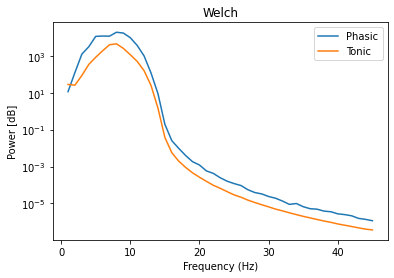

In [10]:
freq = np.arange(1, 46)
plt.plot(freq, phasic_spectrum_mean)
plt.plot(freq, tonic_spectrum_mean)

#plt.fill_between(freq, phasic_spectrum_mean - phasic_spectrum_std,
#                 phasic_spectrum_mean + phasic_spectrum_std, 
#                 alpha=0.5, label='Standard Deviation of Phasic Spectrum')
#
#plt.fill_between(freq, tonic_spectrum_mean - tonic_spectrum_std,
#                 tonic_spectrum_mean + tonic_spectrum_std, 
#                 alpha=0.5, label='Standard Deviation of Tonic Spectrum')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Power [dB]')

plt.yscale('log')
#plt.xscale('log')

plt.title('Welch')
plt.legend(['Phasic', 'Tonic'])

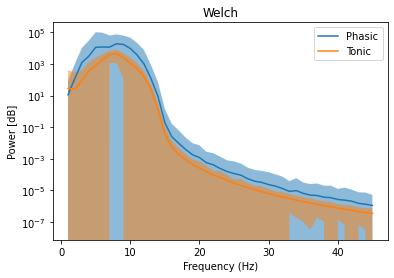

In [11]:
freq = np.arange(1, 46)
plt.plot(freq, phasic_spectrum_mean)
plt.plot(freq, tonic_spectrum_mean)

plt.fill_between(freq, phasic_spectrum_mean - phasic_spectrum_std,
                 phasic_spectrum_mean + phasic_spectrum_std, 
                 alpha=0.5, label='Standard Deviation of Phasic Spectrum')

plt.fill_between(freq, tonic_spectrum_mean - tonic_spectrum_std,
                 tonic_spectrum_mean + tonic_spectrum_std, 
                 alpha=0.5, label='Standard Deviation of Tonic Spectrum')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Power [dB]')

plt.yscale('log')
#plt.xscale('log')

plt.title('Welch')
plt.legend(['Phasic', 'Tonic'])

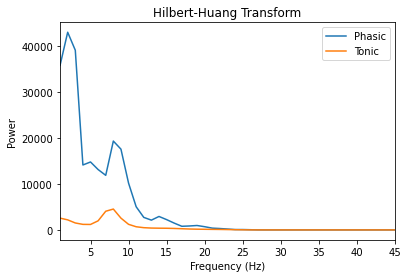

In [12]:
plt.plot(freq, phasic_spectrum_mean)
plt.plot(freq, tonic_spectrum_mean)

#plt.fill_between(freq, phasic_spectrum_mean - phasic_spectrum_std,
#                 phasic_spectrum_mean + phasic_spectrum_std, 
#                 alpha=0.5, label='Standard Deviation of Phasic Spectrum')
#
#plt.fill_between(freq, tonic_spectrum_mean - tonic_spectrum_std,
#                 tonic_spectrum_mean + tonic_spectrum_std, 
#                 alpha=0.5, label='Standard Deviation of Tonic Spectrum')

plt.xlim(1, 45)

plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')

plt.yscale('linear')

plt.title('Hilbert-Huang Transform')
plt.legend(['Phasic', 'Tonic'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7efe0f519d20>,
 'caps': [<matplotlib.lines.Line2D at 0x7efe0f51a2c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7efe0f519a50>,
 'medians': [<matplotlib.lines.Line2D at 0x7efe0f51a860>,
 'fliers': [<matplotlib.lines.Line2D at 0x7efe0f51ab30>,
 'means': []}

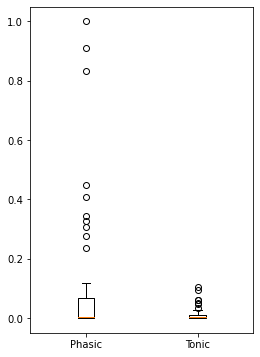

In [14]:
plt.figure(figsize=(4,6))
plt.boxplot([phasic_spectrum_mean/phasic_spectrum_mean.max(),
             tonic_spectrum_mean/phasic_spectrum_mean.max()],
            labels=["Phasic", "Tonic"])

In [21]:
np.save("spectrum_phasic", spectrum_phasic)
np.save("spectrum_tonic", spectrum_tonic)


In [32]:
df_phasic = pd.DataFrame(phasic_spectrum_mean)
df_tonic  = pd.DataFrame(tonic_spectrum_mean)

df_phasic.to_excel("spectrum_phasic.xlsx")
df_tonic.to_excel("spectrum_tonic.xlsx")